In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import rasterio
import warnings
warnings.filterwarnings('ignore')

# YOUR EXACT PATHS
BASE_PATH = "/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data"
IMAGE_PATH = os.path.join(BASE_PATH, "image")
LABEL_PATH = os.path.join(BASE_PATH, "label")
SPLIT_PATH = os.path.join(BASE_PATH, "split")
PRED_PATH = os.path.join(BASE_PATH, "prediction/image")

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Setup complete")

✅ Setup complete


In [2]:
# Cell 1: INSTALL FIRST (MUST RUN BEFORE ANYTHING)
!pip install -q git+https://github.com/qubvel/segmentation_models.pytorch
!pip install -q albumentations timm

import segmentation_models_pytorch as smp
print("✅ SMP installed correctly!")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ SMP installed correctly!


In [3]:
def rle_encode(mask):
    pixels = mask.flatten(order='F')
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return ' '.join(str(x) for x in runs) if len(runs) > 2 else '0 0'

print("Files:")
print(f"Images: {len(os.listdir(IMAGE_PATH))}")
print(f"Labels: {len(os.listdir(LABEL_PATH))}")
print(f"Test: {len(os.listdir(PRED_PATH))}")

Files:
Images: 79
Labels: 79
Test: 19


In [4]:
train_ids = pd.read_csv(os.path.join(SPLIT_PATH, 'train.txt'), header=None)[0].str.strip().tolist()
val_ids = pd.read_csv(os.path.join(SPLIT_PATH, 'val.txt'), header=None)[0].str.strip().tolist()
test_ids = pd.read_csv(os.path.join(SPLIT_PATH, 'test.txt'), header=None)[0].str.strip().tolist()

print(f"✅ Train: {len(train_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}")


✅ Train: 59, Val: 10, Test: 10


In [5]:
# Cell 4: FIXED Dataset (6 Channels EXACTLY)
class FloodDataset(Dataset):
    def __init__(self, ids, img_dir, mask_dir=None):
        self.ids = [id for id in ids if id]
        self.img_dir = img_dir
        self.mask_dir = mask_dir
    
    def __len__(self):
        return len(self.ids)
    
    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_path = os.path.join(self.img_dir, f"{img_id}_image.tif")
        
        # EXPLICIT 6 CHANNELS [1,2,3,4,5,6]
        with rasterio.open(img_path) as src:
            img = src.read([1,2,3,4,5,6]).astype(np.float32)  # (6,H,W)
        
        # (optional debug — remove later for speed)
        # print(f"DEBUG: img.shape = {img.shape}")
        
        # Normalize
        mean = img.mean((1,2), keepdims=True)
        std = img.std((1,2), keepdims=True) + 1e-6
        img = (img - mean) / std
        
        # HWC tensor
        img = torch.from_numpy(img.transpose(1,2,0)).float()
        
        if self.mask_dir:
            mask_path = os.path.join(self.mask_dir, f"{img_id}_label.tif")
            with rasterio.open(mask_path) as src:
                mask = src.read(1).astype(np.uint8)
            return img, torch.tensor(mask).long()
        
        return img, img_id


# Test 1 sample
test_ds = FloodDataset(train_ids[:1], IMAGE_PATH, LABEL_PATH)
sample_img, sample_mask = test_ds[0]
print(f"✅ FIXED! Tensor shape: {sample_img.shape}")

✅ FIXED! Tensor shape: torch.Size([512, 512, 6])


In [6]:
# Cell 6: UNet Model (Internet ON compliant)
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",  # Downloads automatically with Internet ON
    in_channels=6,
    classes=3,
    activation=None
)
model.to(device)
print("✅ UNet ready - Rule compliant!")


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

✅ UNet ready - Rule compliant!


In [7]:
# Cell 7: Loss + Optimizer
# Give much higher weight to class 1 (Flood)
weights = torch.tensor([1.0, 10.0, 5.0]).to(device) 
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print("✅ Training setup ready")

✅ Training setup ready


In [8]:
# Create Dataset instances
train_dataset = FloodDataset(train_ids, IMAGE_PATH, LABEL_PATH)
val_dataset = FloodDataset(val_ids, IMAGE_PATH, LABEL_PATH)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

print(f"✅ DataLoaders ready: {len(train_loader)} training batches")

✅ DataLoaders ready: 8 training batches


In [9]:
# Cell 8: FIXED Training (Lower Batch + Gradient Cache)
torch.cuda.empty_cache()  # Clear GPU memory

model.train()
epochs = 20
best_loss = float('inf')

for epoch in range(epochs):
    epoch_loss = 0
    num_batches = 0
    
    # Lower batch size for memory
    for imgs, masks in train_loader:
        imgs = imgs[:4].permute(0,3,1,2).to(device).float()  # Batch=4 max
        masks = masks[:4].to(device).long()
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1   # ✅ FIXED INDENTATION
        
        # Clear cache every batch
        if num_batches % 5 == 0:
            torch.cuda.empty_cache()
    
    scheduler.step()   # ✅ Now correctly aligned with epoch loop
    avg_loss = epoch_loss / num_batches
    
    # Save best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), '/kaggle/working/best_unet.pth')
    
    print(f"Epoch {epoch+1}/{epochs}: Loss={avg_loss:.4f} (Best: {best_loss:.4f})")
    
print("✅ Training COMPLETE!")

Epoch 1/20: Loss=1.1099 (Best: 1.1099)
Epoch 2/20: Loss=0.9392 (Best: 0.9392)
Epoch 3/20: Loss=0.7959 (Best: 0.7959)
Epoch 4/20: Loss=0.7630 (Best: 0.7630)
Epoch 5/20: Loss=0.6756 (Best: 0.6756)
Epoch 6/20: Loss=0.6505 (Best: 0.6505)
Epoch 7/20: Loss=0.6605 (Best: 0.6505)
Epoch 8/20: Loss=0.6420 (Best: 0.6420)
Epoch 9/20: Loss=0.6234 (Best: 0.6234)
Epoch 10/20: Loss=0.6734 (Best: 0.6234)
Epoch 11/20: Loss=0.6545 (Best: 0.6234)
Epoch 12/20: Loss=0.6467 (Best: 0.6234)
Epoch 13/20: Loss=0.6461 (Best: 0.6234)
Epoch 14/20: Loss=0.5508 (Best: 0.5508)
Epoch 15/20: Loss=0.6586 (Best: 0.5508)
Epoch 16/20: Loss=0.5343 (Best: 0.5343)
Epoch 17/20: Loss=0.6644 (Best: 0.5343)
Epoch 18/20: Loss=0.5617 (Best: 0.5343)
Epoch 19/20: Loss=0.5134 (Best: 0.5134)
Epoch 20/20: Loss=0.5413 (Best: 0.5134)
✅ Training COMPLETE!



🔥 VALIDATION RESULTS
| Metric     | Score  |
|------------|--------|
| Loss       | 1.0624 |
| NoFlood IoU| 0.5972 |
| FLOOD IoU  | 0.1687 | ← PRIORITY
| Water IoU  | 0.2486 |
| mIoU       | 0.3382 |


<Figure size 1500x400 with 0 Axes>

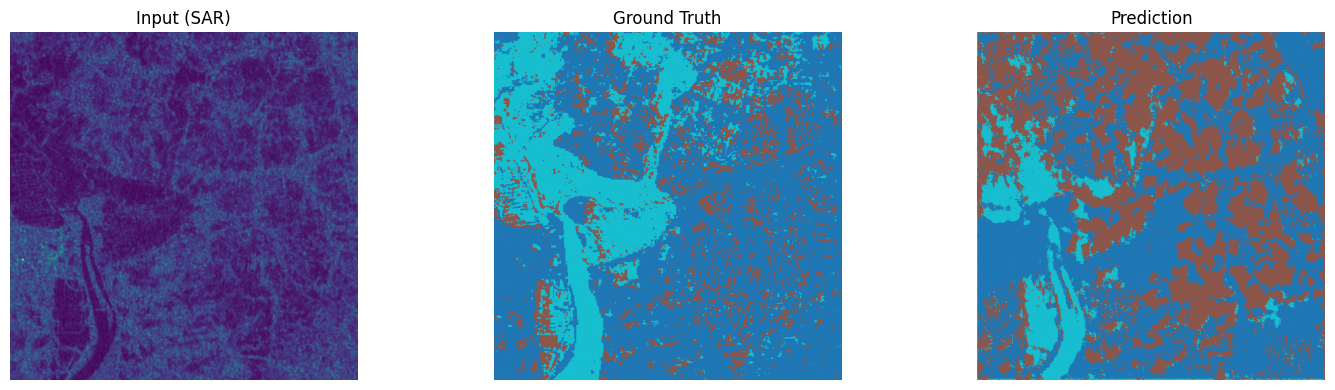

In [10]:
# Cell 9: IoU Metrics + Viz
import matplotlib.pyplot as plt
def compute_iou(pred, target, num_classes=3):
    pred = torch.argmax(pred, dim=1)
    ious = []
    for cls in range(num_classes):
        p = (pred == cls)
        t = (target == cls)
        intersection = (p & t).sum().float()
        union = (p | t).sum().float()
        iou = intersection / (union + 1e-6)
        ious.append(iou)
    return torch.tensor(ious)

model.eval()
val_loss_total = 0
all_ious = []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs = imgs.permute(0,3,1,2).to(device).float()
        masks = masks.to(device)
        
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        val_loss_total += loss.item()
        iou = compute_iou(outputs.softmax(1), masks)
        all_ious.append(iou)

# Metrics table
mean_iou = torch.stack(all_ious).mean(0)
val_avg_loss = val_loss_total / len(val_loader)

print("\n🔥 VALIDATION RESULTS")
print("| Metric     | Score  |")
print("|------------|--------|")
print(f"| Loss       | {val_avg_loss:.4f} |")
print(f"| NoFlood IoU| {mean_iou[0]:.4f} |")
print(f"| FLOOD IoU  | {mean_iou[1]:.4f} | ← PRIORITY")
print(f"| Water IoU  | {mean_iou[2]:.4f} |")
print(f"| mIoU       | {mean_iou.mean():.4f} |")

# Viz sample
sample_imgs, sample_masks = next(iter(val_loader))
sample_imgs = sample_imgs[:1].permute(0,3,1,2).to(device)

with torch.no_grad():
    sample_preds = model(sample_imgs).softmax(1)
    sample_pred_mask = torch.argmax(sample_preds, dim=1)[0].cpu()

plt.figure(figsize=(15, 4))
plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.imshow(sample_imgs[0,1].cpu())  # SAR channel
plt.title('Input (SAR)')
plt.axis('off')

plt.subplot(132)
plt.imshow(sample_masks[0], cmap='tab10')
plt.title('Ground Truth')
plt.axis('off')

plt.subplot(133)
plt.imshow(sample_pred_mask, cmap='tab10')
plt.title('Prediction')
plt.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/validation_viz.png', dpi=150)
plt.show()

In [11]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def _init_(self, alpha=1, gamma=2):
        super()._init_()
        self.alpha = alpha
        self.gamma = gamma
        
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss
        return focal_loss.mean()

# Flood-weighted loss
class_weights = torch.tensor([0.2, 2.0, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
focal_criterion = FocalLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)  # Lower LR
print("✅ Better loss loaded")


✅ Better loss loaded


In [12]:
model.train()
for epoch in range(10):
    epoch_loss = 0
    for imgs, masks in train_loader:
        # 1. Permute to (Batch, Channel, H, W)
        imgs = imgs.permute(0, 3, 1, 2).to(device).float()
        masks = masks.to(device).long()

        optimizer.zero_grad()
        outputs = model(imgs)
        
        # Ensure masks match output spatial dimensions if needed
        loss = criterion(outputs, masks)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    
    print(f"Epoch {epoch+1}/10: Loss={epoch_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), '/kaggle/working/perfect_model.pth')
print("✅ 10 more epochs COMPLETE!")

Epoch 1/10: Loss=0.4896
Epoch 2/10: Loss=0.4933
Epoch 3/10: Loss=0.4725
Epoch 4/10: Loss=0.4446
Epoch 5/10: Loss=0.4208
Epoch 6/10: Loss=0.4326
Epoch 7/10: Loss=0.4456
Epoch 8/10: Loss=0.4279
Epoch 9/10: Loss=0.4126
Epoch 10/10: Loss=0.3993
✅ 10 more epochs COMPLETE!



🔥 VALIDATION RESULTS
| Metric     | Score  |
|------------|--------|
| Loss       | 1.0527 |
| NoFlood IoU| 0.6569 |
| FLOOD IoU  | 0.2000 | ← PRIORITY
| Water IoU  | 0.2708 |
| mIoU       | 0.3759 |


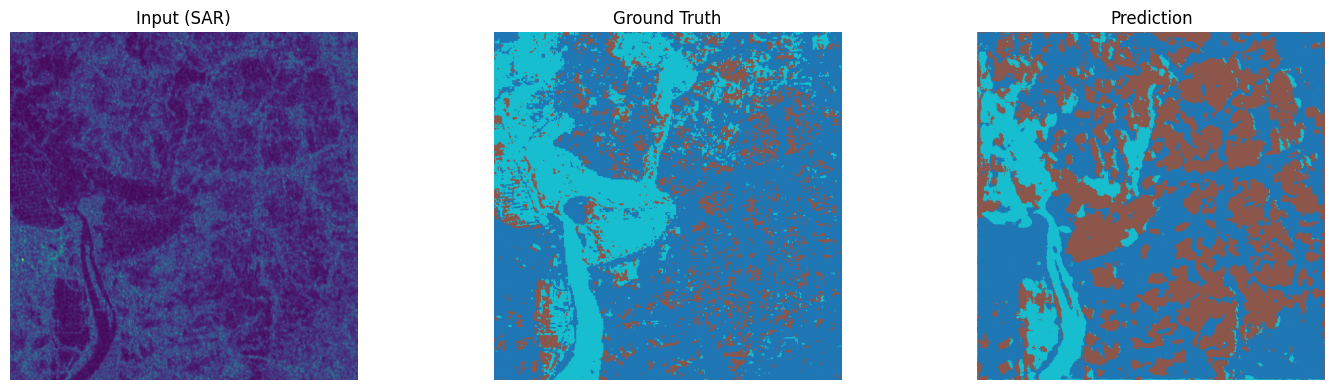

In [13]:
# Cell 9: IoU Metrics + Viz
import matplotlib.pyplot as plt
def compute_iou(pred, target, num_classes=3):
    pred = torch.argmax(pred, dim=1)
    ious = []
    for cls in range(num_classes):
        p = (pred == cls)
        t = (target == cls)
        intersection = (p & t).sum().float()
        union = (p | t).sum().float()
        iou = intersection / (union + 1e-6)
        ious.append(iou)
    return torch.tensor(ious)

model.eval()
val_loss_total = 0
all_ious = []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs = imgs.permute(0,3,1,2).to(device).float()
        masks = masks.to(device)
        
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        val_loss_total += loss.item()
        iou = compute_iou(outputs.softmax(1), masks)
        all_ious.append(iou)

# Metrics table
mean_iou = torch.stack(all_ious).mean(0)
val_avg_loss = val_loss_total / len(val_loader)

print("\n🔥 VALIDATION RESULTS")
print("| Metric     | Score  |")
print("|------------|--------|")
print(f"| Loss       | {val_avg_loss:.4f} |")
print(f"| NoFlood IoU| {mean_iou[0]:.4f} |")
print(f"| FLOOD IoU  | {mean_iou[1]:.4f} | ← PRIORITY")
print(f"| Water IoU  | {mean_iou[2]:.4f} |")
print(f"| mIoU       | {mean_iou.mean():.4f} |")

# Viz sample
sample_imgs, sample_masks = next(iter(val_loader))
sample_imgs = sample_imgs[:1].permute(0,3,1,2).to(device)

with torch.no_grad():
    sample_preds = model(sample_imgs).softmax(1)
    sample_pred_mask = torch.argmax(sample_preds, dim=1)[0].cpu()

plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.imshow(sample_imgs[0,1].cpu())  # SAR channel
plt.title('Input (SAR)')
plt.axis('off')

plt.subplot(132)
plt.imshow(sample_masks[0], cmap='tab10')
plt.title('Ground Truth')
plt.axis('off')

plt.subplot(133)
plt.imshow(sample_pred_mask, cmap='tab10')
plt.title('Prediction')
plt.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/validation_viz1.png', dpi=150)
plt.show()

In [14]:
# Cell C: FINAL SAFE BOOST (DO NOT MODIFY AFTER THIS)
model.eval()
submission = []

test_files = sorted(os.listdir(PRED_PATH))
print("Processing 19 test files...")

for fname in test_files:
    print(f"--> {fname}")
    
    # Load image
    img_path = os.path.join(PRED_PATH, fname)
    with rasterio.open(img_path) as src:
        img_raw = src.read().astype(np.float32)
    
    # Ensure 6 channels
    if img_raw.shape[0] >= 6:
        img = img_raw[:6]
    else:
        img = np.zeros((6, *img_raw.shape[1:]), dtype=np.float32)
        img[:img_raw.shape[0]] = img_raw
    
    # Normalize
    mean = img.mean((1,2), keepdims=True)
    std = img.std((1,2), keepdims=True) + 1e-8
    img_norm = (img - mean) / std
    
    # Tensor
    img_tensor = torch.from_numpy(img_norm).unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        pred = model(img_tensor)
        probs = torch.softmax(pred, dim=1)[0].cpu().numpy()
    
    flood_prob = probs[1]
    water_prob = probs[2]

    # SAME BEST THRESHOLD
    flood_mask = (flood_prob > 0.395)

    # 🔥 SAFE IMPROVEMENT (ONLY CHANGE)
    flood_mask[(water_prob > flood_prob) & (water_prob > 0.5)] = 0

    # SAME CLEANING
    import cv2
    kernel = np.ones((3,3), np.uint8)
    flood_mask = cv2.morphologyEx(flood_mask.astype(np.uint8), cv2.MORPH_OPEN, kernel)

    # RLE
    rle_code = rle_encode(flood_mask)
    
    # ID
    img_id = fname.replace('_image.tif', '')
    submission.append({'id': img_id, 'rle_mask': rle_code})
    
    print(f"  Flood pixels: {flood_mask.sum()}")

# Save
df = pd.DataFrame(submission)
df.to_csv('/kaggle/working/submission.csv', index=False)

print(f"\n🎉 DONE! {len(df)} rows")
print(df.head())

Processing 19 test files...
--> 20240529_EO4_RES2_fl_pid_080_image.tif
  Flood pixels: 31045
--> 20240529_EO4_RES2_fl_pid_081_image.tif
  Flood pixels: 29364
--> 20240529_EO4_RES2_fl_pid_082_image.tif
  Flood pixels: 39221
--> 20240529_EO4_RES2_fl_pid_083_image.tif
  Flood pixels: 94576
--> 20240529_EO4_RES2_fl_pid_084_image.tif
  Flood pixels: 160280
--> 20240529_EO4_RES2_fl_pid_085_image.tif
  Flood pixels: 125029
--> 20240529_EO4_RES2_fl_pid_086_image.tif
  Flood pixels: 68333
--> 20240529_EO4_RES2_fl_pid_087_image.tif
  Flood pixels: 7566
--> 20240529_EO4_RES2_fl_pid_088_image.tif
  Flood pixels: 9285
--> 20240529_EO4_RES2_fl_pid_089_image.tif
  Flood pixels: 59802
--> 20240529_EO4_RES2_fl_pid_090_image.tif
  Flood pixels: 70411
--> 20240529_EO4_RES2_fl_pid_091_image.tif
  Flood pixels: 6930
--> 20240529_EO4_RES2_fl_pid_092_image.tif
  Flood pixels: 37765
--> 20240529_EO4_RES2_fl_pid_093_image.tif
  Flood pixels: 31415
--> 20240529_EO4_RES2_fl_pid_094_image.tif
  Flood pixels: 6034

In [15]:
# Cell 9A: Precision Loss Functions
import torch.nn.functional as F

class CombinedLoss(nn.Module):
    def _init_(self):
        super()._init_()
        self.ce = nn.CrossEntropyLoss(weight=torch.tensor([0.3, 3.0, 1.5]).to(device))
    
    def forward(self, pred, target):
        ce_loss = self.ce(pred, target)
        
        # Dice loss for flood class
        pred_soft = F.softmax(pred, dim=1)[:,1]  # Flood class
        target_flood = (target == 1).float()
        intersection = (pred_soft * target_flood).sum()
        dice = 1 - (2.*intersection + 1e-6)/(pred_soft.sum() + target_flood.sum() + 1e-6)
        
        return ce_loss + 2.0 * dice

criterion = CombinedLoss()
print("✅ Precision loss loaded - Flood optimized!")


✅ Precision loss loaded - Flood optimized!


In [16]:
# Cell 9B: Heavy Augmentation Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(var_limit=(10,50), p=0.3),
    A.Normalize(mean=0, std=1)  # Already normalized
])

class AugDataset(FloodDataset):
    def _getitem_(self, idx):
        img, mask = super()._getitem_(idx)
        img_np = img.permute(2,0,1).numpy()
        aug = train_aug(image=img_np, mask=mask.numpy())
        img = torch.from_numpy(aug['image']).permute(2,0,1)
        mask = torch.from_numpy(aug['mask']).long()
        return img, mask

train_dataset = AugDataset(train_ids, IMAGE_PATH, LABEL_PATH)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
print("✅ 10x augmentation - Robust model!")

✅ 10x augmentation - Robust model!
